In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.stats import poisson
import pandas as pd
from astropy.io import fits
from astropy.io import fits
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [4]:
# Routine to project to Cartesian
from utils.cart import make_wcs, to_cart

In [5]:
cmap = 'RdBu_r'

In [6]:
! nvidia-smi

zsh:1: command not found: nvidia-smi


## _Fermi_ data

In [7]:
# Load and downsamples Fermi counts data

counts_fits = fits.open("../data/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 20
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data),int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [8]:
# Load and downsample exposure

exposure = fits.open("../data/exposure_ultracleanveto_bestpsf_joined.fits")
exposure = exposure[0].data[:, int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = exposure.shape[1] // upsample_factor

In [9]:
# Interpolate exposure to the Zenodo map energy bins

e_min_interp = np.array(counts_fits[1].data[:])['E_MIN'] / 1e3
exposure_interp = interp1d(e_min_interp, exposure, axis=0)
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38) 
exposure_interp = exposure_interp(e_bins).reshape(len(e_bins), -1, upsample_factor, b, upsample_factor).mean((-1, -3))

## Templates

In [10]:
extent = 20  # Semi-extent in degrees
n_pixels = 80  # Number of pixels
pixelsize = 2 * extent / n_pixels
nside = 128

In [11]:
# Load standard templates and convert to Cartesian
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

In [12]:
np.max(counts_downsampled[~mask_roi])

278

## Test opening Zenodo maps

In [24]:
zenodo_dir = "/Users/smsharma/Downloads/"  # Directory where Zenodo maps are located

In [13]:
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38) / 1e3 
e_bins_widths = (e_bins[1:] - e_bins[:-1])
e_bins_centers = (e_bins[1:] + e_bins[:-1]) / 2

In [14]:
# Select energy bins closest to 2 and 20 GeV
e_bin_min_idx = np.argmin(np.abs(e_bins - 2)) #- 1
e_bin_max_idx = np.argmin(np.abs(e_bins - 20)) #- 1

In [15]:
pixel_size_data = 0.25
pixel_size_target = 0.5
extent = 20
upsample_factor = int(pixel_size_target / pixel_size_data)

In [20]:
# Names of Zenodo diffuse models
dif_names = pd.read_csv('/Users/smsharma/Downloads/ZENODO_FILES/NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat', skiprows=1, header=None, delim_whitespace=True)[1].tolist()

In [21]:
dif = dif_names[0]  # Test opening first model

temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

for dif_type in ['bremss', 'pi0', 'ICS']:
    file = fits.open("/Users/smsharma/Downloads/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(dif_type, dif))
    phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
    n_pix_edge = int((30 - extent) / pixel_size_data)
    n_pix_total = int(2 * extent / pixel_size_data)
    phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
    b = phi.shape[1] // upsample_factor
    phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
    phi *= np.deg2rad(pixel_size_target ** 2)
    phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
    phi /= 1e3
    temp_ary.append(phi[:, ::-1])
    
temp_ary = np.array(temp_ary)
temp_ary.mean((1,2))

array([1.81925063, 2.65140222, 1.01145826, 1.45589663, 1.01161281,
       1.76010477, 2.80611999, 2.93967859])

## Poisson fits

In [25]:
def likelihood(theta, data, mask=None):
    """ Pixel-wise product Poisson log-likelihood
    """ 
    if mask is None:
        mask = np.zeros(temp_ary[0].shape, dtype=bool)
    temp_sum = np.einsum("ik, i -> k", temp_ary[:, ~mask], theta)
    return -poisson.logpmf(data[~mask], temp_sum).mean()

def likelihood_map(theta, data, mask=None):
    """ Maps of Poisson likelihood per-pixel
    """ 
    if mask is None:
        mask = np.zeros(temp_ary[0].shape, dtype=bool)
    temp_sum = np.einsum("ikj, i -> kj", temp_ary, theta)
    return poisson.logpmf(data, temp_sum) * ~mask

### Standard ROI (PS + lat mask)

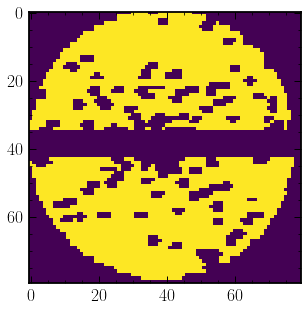

In [26]:
plt.imshow(~mask_roi)

In [27]:
ll_list = []
opt_list = []
ll_map_list = []

for dif in tqdm(dif_names):
    
    temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

    for dif_type in ['pi0', 'bremss', 'ICS']:
        file = fits.open("{}/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(zenodo_dir, dif_type, dif))
        
        # The Zenodo maps are given ni E^2 dN/dE; convert them to just expected intensity

        phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
        n_pix_edge = int((30 - extent) / pixel_size_data)
        n_pix_total = int(2 * extent / pixel_size_data)
        phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
        b = phi.shape[1] // upsample_factor
        phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
        phi *= np.deg2rad(pixel_size_target ** 2)
        phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
        phi /= 1e3
        temp_ary.append(phi[:, ::-1])

    temp_ary = np.array(temp_ary)

    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi), bounds=[[0, 20]] * len(temp_ary))
    ll_data = - opt.fun
    ll_map = likelihood_map(opt.x, counts_downsampled, mask_roi)
    
    opt_list.append(opt)
    ll_list.append(ll_data) 
    ll_map_list.append(ll_map)

In [25]:
np.array([opt_list[i].x[0] for i in range(len(dif_names))])[np.argmax(np.array(ll_list) * (~mask_roi).sum())]

1.4570847438556151

In [30]:
# Do fits for p6 and Model O

temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, temp_dif_cart])
ll_p6 = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, temp_mO_pibrem_cart, temp_mO_ics_cart])
ll_mO = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

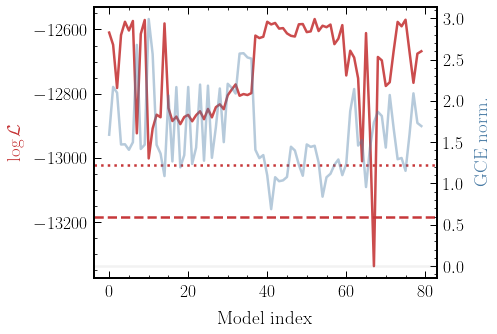

In [31]:
fig, ax1 = plt.subplots()

ax1.plot(np.array(ll_list) * (~mask_roi).sum())
ax1.axhline(ll_p6 * (~mask_roi).sum(), color=cols_default[0], ls='dashed')
ax1.axhline(ll_mO * (~mask_roi).sum(), color=cols_default[0], ls='dotted')

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)

## Quadrants

In [32]:
ll_list_quadrants = []
opt_list_quadrants = []
ll_map_list_quadrants = []

for dif in tqdm(dif_names):
    
    temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

    for dif_type in ['pi0', 'bremss', 'ICS']:
        file = fits.open("{}/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(zenodo_dir, dif_type, dif))
        
        # The Zenodo maps are given ni E^2 dN/dE; convert them to just expected intensity
        
        phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
        n_pix_edge = int((30 - extent) / pixel_size_data)
        n_pix_total = int(2 * extent / pixel_size_data)
        phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
        b = phi.shape[1] // upsample_factor
        phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
        phi *= np.deg2rad(pixel_size_target ** 2)
        phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
        phi /= 1e3
        phi = phi[:, ::-1]
        
        # Create quadrant templates
        
        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[:int(n_pixels / 2), :int(n_pixels / 2)] = phi[:int(n_pixels / 2), :int(n_pixels / 2)]
        temp_ary.append(temp_temp_dif)

        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[:int(n_pixels / 2), int(n_pixels / 2):] = phi[:int(n_pixels / 2), int(n_pixels / 2):]
        temp_ary.append(temp_temp_dif)

        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[int(n_pixels / 2):, :int(n_pixels / 2)] = phi[int(n_pixels / 2):, :int(n_pixels / 2)]
        temp_ary.append(temp_temp_dif)

        temp_temp_dif = np.zeros((n_pixels, n_pixels))
        temp_temp_dif[int(n_pixels / 2):, int(n_pixels / 2):] = phi[int(n_pixels / 2):, int(n_pixels / 2):]
        temp_ary.append(temp_temp_dif)
    
    temp_ary = np.array(temp_ary)

    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi), bounds=[[0, 20]] * len(temp_ary))
    ll_data = - opt.fun
    ll_map = likelihood_map(opt.x, counts_downsampled, mask_roi)

    opt_list_quadrants.append(opt)
    ll_list_quadrants.append(ll_data) 
    ll_map_list_quadrants.append(ll_map) 

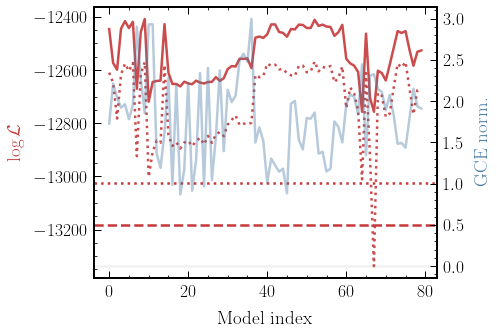

In [62]:
fig, ax1 = plt.subplots()

ax1.plot(np.array(ll_list_quadrants) * (~mask_roi).sum())
ax1.plot(np.array(ll_list) * (~mask_roi).sum(), ls='dotted', color=cols_default[0])
ax1.axhline(ll_p6 * (~mask_roi).sum(), color=cols_default[0], ls='dashed')
ax1.axhline(ll_mO * (~mask_roi).sum(), color=cols_default[0], ls='dotted')

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list_quadrants[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)

Text(0, 0.5, '$\\log\\mathcal L$')

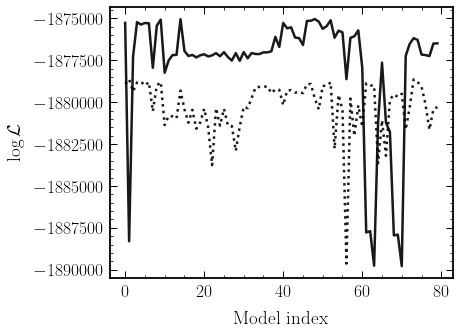

In [85]:
logl_paper = pd.read_csv("{}/ZENODO_FILES/GCE_Models_LogLikelihoods_2021_DMprofiles_October_GCE_vs_Background.dat".format(zenodo_dir), skiprows=1, header=None, delim_whitespace=True)

fig, ax1 = plt.subplots()

ax1.plot(logl_paper[1], color='k')
ax1.plot(logl_paper[5], color='k', ls=':')

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$")


In [86]:
logl_paper[0][np.argsort(logl_paper[1])[-4:]]

52    LIII
9        X
14      XV
48    XLIX
Name: 0, dtype: object

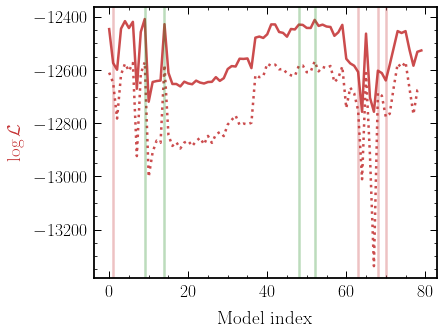

In [80]:
fig, ax1 = plt.subplots()

ax1.plot(np.array(ll_list_quadrants) * (~mask_roi).sum())
ax1.plot(np.array(ll_list) * (~mask_roi).sum(), ls='dotted', color=cols_default[0])
# ax1.axhline(ll_p6 * (~mask_roi).sum(), color=cols_default[0], ls='dashed')
# ax1.axhline(ll_mO * (~mask_roi).sum(), color=cols_default[0], ls='dotted')

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

# ax2 = ax1.twinx()
# ax2.plot(np.array([opt_list_quadrants[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
# ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)

for idx in np.argsort(logl_paper[1])[:4]:
    plt.axvline(idx, alpha=0.3)
    
for idx in np.argsort(logl_paper[1])[-4:]:
    plt.axvline(idx, color='forestgreen', alpha=0.3)

## Remove badly-fit pixels

Text(0.5, 1.0, 'Badly-fit pixels')

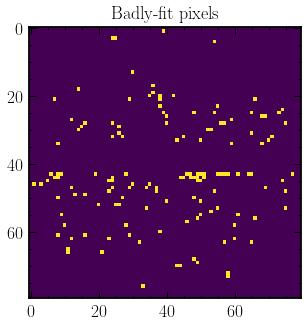

In [44]:
bad_pixels = np.zeros((n_pixels, n_pixels))

for ll_map in ll_map_list_quadrants:
    test_mask = ll_map < -8  # LL treshold at which to remove pixel
    bad_pixels += test_mask
    
bad_pixels = bad_pixels > 0
plt.imshow(bad_pixels)
plt.title("Badly-fit pixels")

In [34]:
ll_list_quadrants_badexcluded = []
for ll_map in ll_map_list_quadrants:
    ll_list_quadrants_badexcluded.append(ll_map.flatten()[~bad_pixels.flatten()].sum())

Text(0.5, 1.0, 'Best fit model')

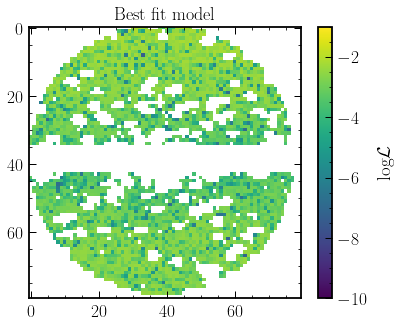

In [35]:
plt.imshow(np.ma.masked_array(ll_map_list_quadrants[np.argmax(np.array(ll_list_quadrants))], mask_roi + bad_pixels > 0 ), vmin=-10, vmax=-1)
plt.colorbar(label="$\mathrm{log}\mathcal L$")
plt.title("Best fit model")

Text(0.5, 1.0, 'Worst fit model')

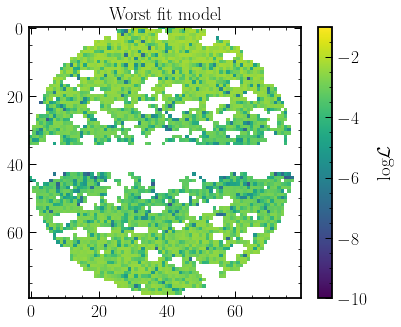

In [36]:
plt.imshow(np.ma.masked_array(ll_map_list_quadrants[np.argmin(np.array(ll_list_quadrants))], mask_roi + bad_pixels > 0 ), vmin=-10, vmax=-1)
plt.colorbar(label="$\mathrm{log}\mathcal L$")
plt.title("Worst fit model")

Text(0.5, 1.0, 'Difference between best- and worst-fit models')

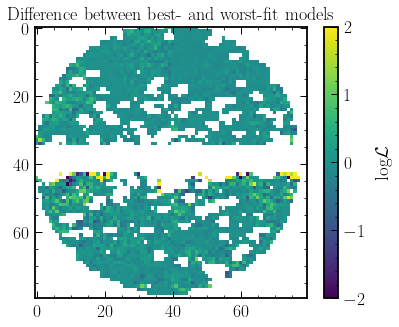

In [37]:
plt.imshow(np.ma.masked_array(ll_map_list_quadrants[np.argmax(np.array(ll_list_quadrants))] - ll_map_list_quadrants[np.argmin(np.array(ll_list_quadrants))], mask_roi + bad_pixels > 0 ), vmin=-2, vmax=2)
plt.colorbar(label="$\mathrm{log}\mathcal L$")
plt.title("Difference between best- and worst-fit models")

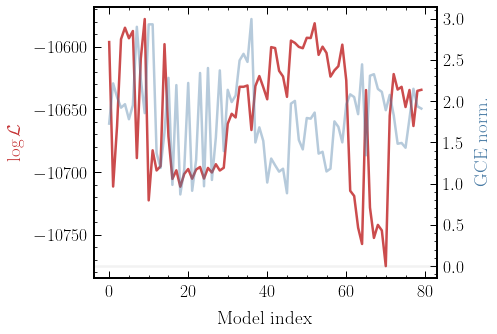

In [38]:
fig, ax1 = plt.subplots()

ax1.plot(ll_list_quadrants_badexcluded)

ax1.set_xlabel("Model index")
ax1.set_ylabel("$\log\mathcal L$", color=cols_default[0])

ax2 = ax1.twinx()
ax2.plot(np.array([opt_list_quadrants[i].x[0] for i in range(len(dif_names))]), color=cols_default[1], alpha=0.4)
ax2.set_ylabel("GCE norm.", color=cols_default[1])

ax2.axhline(0, color='grey', alpha=0.1)